<a href="https://colab.research.google.com/github/atticuszhou288-maker/Final-Project-of-Data-Science-for-Biology-and-Medicine/blob/main/Spatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Final Project')

!pip install -q scanpy decoupler matplotlib seaborn pandas numpy scikit-learn

import scanpy as sc
import decoupler as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sc.settings.verbosity = 1
sc.set_figure_params(dpi=100, frameon=False, color_map='viridis')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.5/86.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the

In [ ]:
train_T = pd.read_csv("counts_train_valid_masked.csv", index_col=0).T
train_label = pd.read_csv("meta_train_valid.csv", index_col=0)
train_label.columns = ['spatial_domain']


print("NaNs before:", train_T.isna().sum().sum())
train_T = train_T.fillna(0.0)
for col in train_T.columns:
    if train_T[col].dtype == 'object':
        train_T[col] = pd.to_numeric(train_T[col], errors='coerce').fillna(0.0)


adata = sc.AnnData(train_T)
adata.obs['spatial_domain'] = train_label['spatial_domain']


sc.pp.filter_cells(adata, min_genes=5)
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(f"Train+Valid spots after QC: {adata.n_obs}, genes: {adata.n_vars}")

NaNs before: 234600
Train+Valid spots after QC: 2975, genes: 15758


In [ ]:
immune_markers_extended = {
    'CD8_T_cells': ['CD8A','CD8B','GZMA','GZMB','GZMK','PRF1','GNLY','NKG7','CST7','CCL5'],
    'CD4_T_cells': ['CD4','CD40LG','IL7R','CCR7','SELL','LEF1','TCF7','MAL','TRAT1'],
    'T_reg': ['FOXP3','IL2RA','CTLA4','TNFRSF18','IKZF2','IL2RB','TIGIT'],
    'B_cells': ['CD19','MS4A1','CD79A','CD79B','BLK','PAX5','BANK1','CD22','FCRL5'],
    'Plasma_cells': ['SDC1','MZB1','IGHG1','IGKC','JCHAIN','XBP1'],
    'NK_cells': ['NKG7','KLRD1','KLRF1','PRF1','KLRB1','NCR1','GNLY'],
    'Macrophages': ['CD68','CD163','MSR1','CSF1R','ITGAM','CD14','FCGR3A','S100A8','C1QA'],
    'Dendritic_cells': ['CLEC10A','FCER1A','CLEC9A','XCR1','BATF3','IRF8','FLT3'],
    'Mast_cells': ['KIT','CPA3','TPSAB1','HDC','MS4A2'],
    'Cytotoxicity': ['GZMA','GZMB','GZMH','PRF1','GNLY','FASLG'],
    'MHC_I': ['HLA-A','HLA-B','HLA-C','B2M','TAP1','TAP2','NLRC5'],
    'MHC_II': ['HLA-DRA','HLA-DRB1','HLA-DQA1','HLA-DPA1','CD74','CIITA'],
    'Co_inhibitory': ['PDCD1','CD274','CTLA4','HAVCR2','LAG3','TIGIT'],
    'Co_stimulatory': ['CD27','CD28','ICOS','TNFRSF9','CD40','CD80','CD86'],
    'TLS_fibroblast': ['CXCL13','CCL19','CCL21','CCR7','LTB','VCAM1','ICAM1'],
}


gene_sets = {}
for ct, genes in immune_markers_extended.items():
    available = [g for g in genes if g in adata.var_names]
    if len(available) >= 4:
        gene_sets[ct] = available
    else:
        print(f"Warning: {ct} only {len(available)} genes, skipped.")

print(f"Final gene sets: {len(gene_sets)} cell types")

Final gene sets: 14 cell types


In [14]:
import numpy as np
import scipy.stats as stats

def ssgsea_score(expr, gene_set):

    sorted_indices = np.argsort(-expr)

    in_set = np.isin(sorted_indices, gene_set).astype(int)
    n = len(expr)
    n_genes = len(gene_set)
    step_up = 1.0 / n_genes
    step_down = 1.0 / (n - n_genes)

    running_sum = 0.0
    max_es = 0.0
    for i in range(n):
        if in_set[i]:
            running_sum += step_up
        else:
            running_sum -= step_down
        max_es = max(max_es, running_sum)
    return max_es

if hasattr(adata.X, 'toarray'):
    X = adata.X.toarray()
else:
    X = adata.X
X = X.T
gene_to_idx = {gene: i for i, gene in enumerate(adata.var_names)}

final_sets = {}
for ct, genes in gene_sets.items():

    indices = [gene_to_idx[g] for g in genes if g in gene_to_idx]
    if len(indices) >= 3:
        gene_set_indices[ct] = indices
        final_sets[ct] = [g for g in genes if g in gene_to_idx]
    else:
        print(f"Warning: {ct} only {len(indices)} genes, skipped.")

print(f"Final gene sets: {len(gene_set_indices)}")


score_cols = list(gene_set_indices.keys())
scores = np.zeros((adata.n_obs, len(score_cols)))

for i, ct in enumerate(score_cols):
    idx = gene_set_indices[ct]
    for j in range(adata.n_obs):
        scores[j, i] = ssgsea_score(X[:, j], idx)

for i, ct in enumerate(score_cols):
    adata.obs[ct] = scores[:, i]

print(adata.obs[score_cols].head())

Final gene sets: 14
         CD8_T_cells  CD4_T_cells     T_reg   B_cells  Plasma_cells  NK_cells  \
g10-104     0.090101     0.065408  0.046900  0.127238      0.346855  0.105581   
g10-117     0.090228     0.266775  0.399449  0.127048      0.208481  0.128990   
g10-131     0.090164     0.059122  0.046646  0.127111      0.270802  0.130713   
g10-32      0.378260     0.075081  0.050663  0.063810      0.489271  0.128291   
g10-35      0.090101     0.005461  0.000127  0.051746      0.446927  0.093454   

         Macrophages  Dendritic_cells  Mast_cells  Cytotoxicity     MHC_I  \
g10-104     0.144672         0.162974    0.307604      0.178454  0.423099   
g10-117     0.506847         0.238271    0.307858      0.345734  0.471309   
g10-131     0.311025         0.155990    0.307731      0.174454  0.423226   
g10-32      0.576248         0.065202    0.207408      0.279605  0.675321   
g10-35      0.223288         0.052886    0.169036      0.060373  0.262092   

         Co_inhibitory  Co_sti

In [15]:
X = adata.obs[score_cols].values
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
adata.obs['immune_cluster'] = kmeans.fit_predict(X_scaled).astype(str)

cluster_means = adata.obs.groupby('immune_cluster')[score_cols].mean()
mean_total = cluster_means.mean(axis=1).sort_values(ascending=False)
mapping = {mean_total.index[0]: 'Immune_High',
           mean_total.index[1]: 'Immune_Mid',
           mean_total.index[2]: 'Immune_Low'}
adata.obs['immune_type'] = adata.obs['immune_cluster'].map(mapping)

print(cluster_means)
print(mapping)

                CD8_T_cells  CD4_T_cells     T_reg   B_cells  Plasma_cells  \
immune_cluster                                                               
0                  0.103821     0.150660  0.121149  0.146333      0.430131   
1                  0.196743     0.337709  0.343643  0.153885      0.549303   
2                  0.092427     0.035740  0.012626  0.105215      0.350747   

                NK_cells  Macrophages  Dendritic_cells  Mast_cells  \
immune_cluster                                                       
0               0.117062     0.329375         0.205736    0.315247   
1               0.137400     0.341731         0.238096    0.317435   
2               0.107393     0.240928         0.106901    0.284967   

                Cytotoxicity     MHC_I  Co_inhibitory  Co_stimulatory  \
immune_cluster                                                          
0                   0.242844  0.491511       0.398540        0.156644   
1                   0.338752  0.489778 

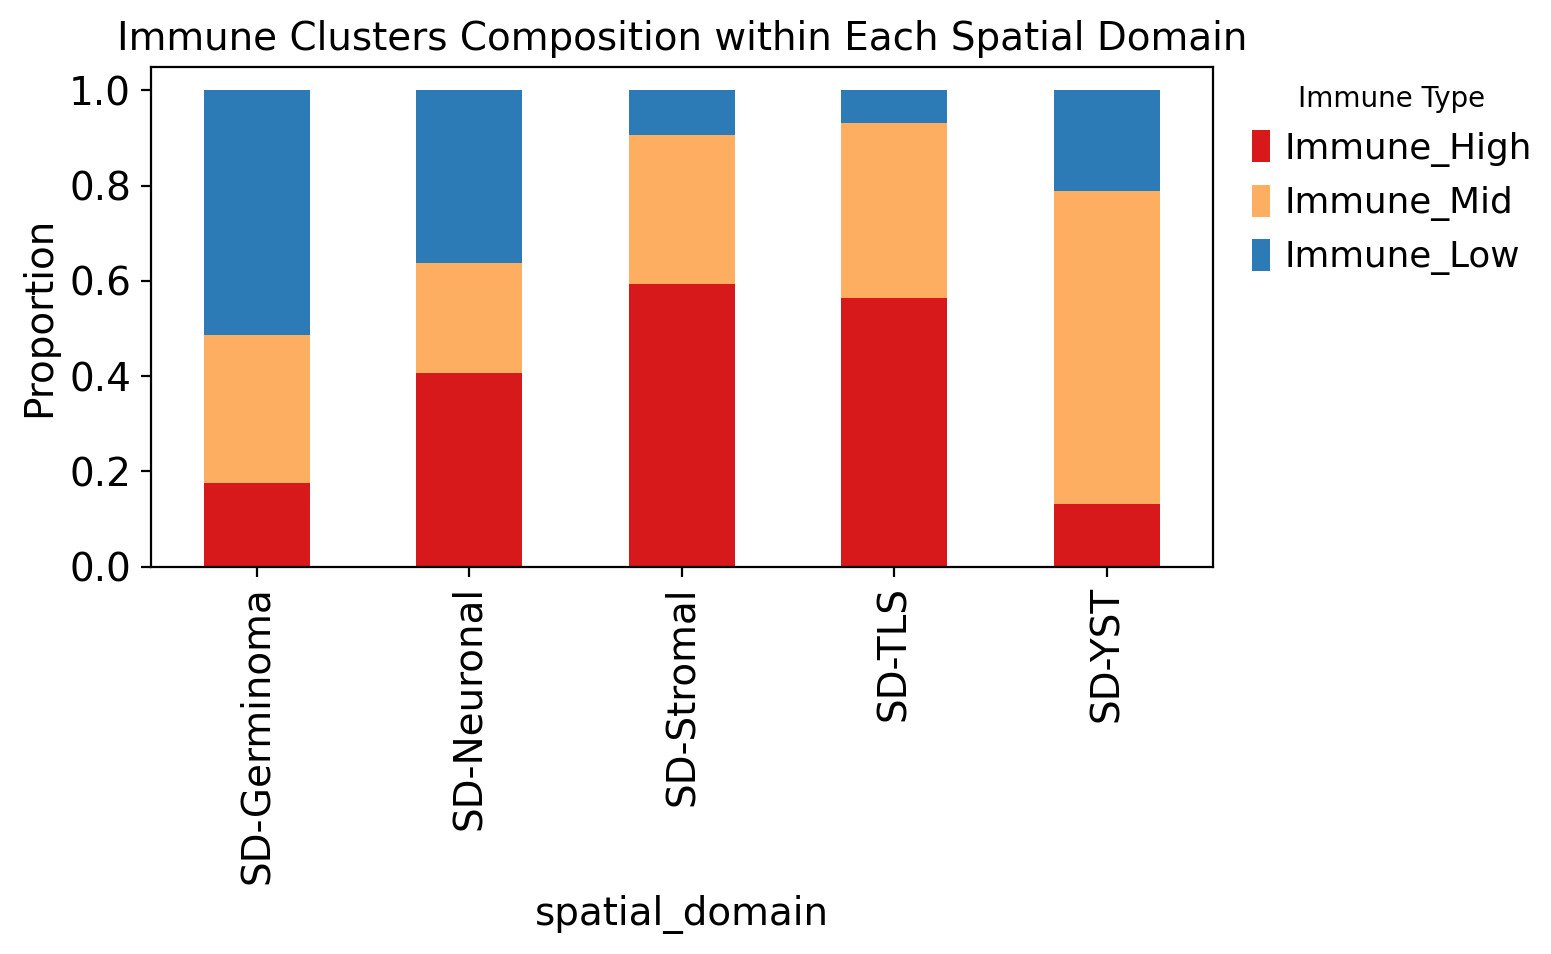

In [22]:
contingency = pd.crosstab(adata.obs['spatial_domain'], adata.obs['immune_type'], normalize='index')
order = ['Immune_High', 'Immune_Mid', 'Immune_Low']
contingency = contingency[order]
color_dict = {'Immune_High': '#d7191c', 'Immune_Mid': '#fdae61', 'Immune_Low': '#2c7bb6'}

ax = contingency.plot(kind='bar', stacked=True, figsize=(8,5),
                      color=[color_dict[c] for c in contingency.columns])
ax.set_title('Immune Clusters Composition within Each Spatial Domain')
ax.set_ylabel('Proportion')
ax.grid(False)

ax.legend(title='Immune Type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('immune_cluster_by_SD.pdf', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6283/779484954.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  domain_means = adata.obs.groupby('spatial_domain')[key_cts].mean()


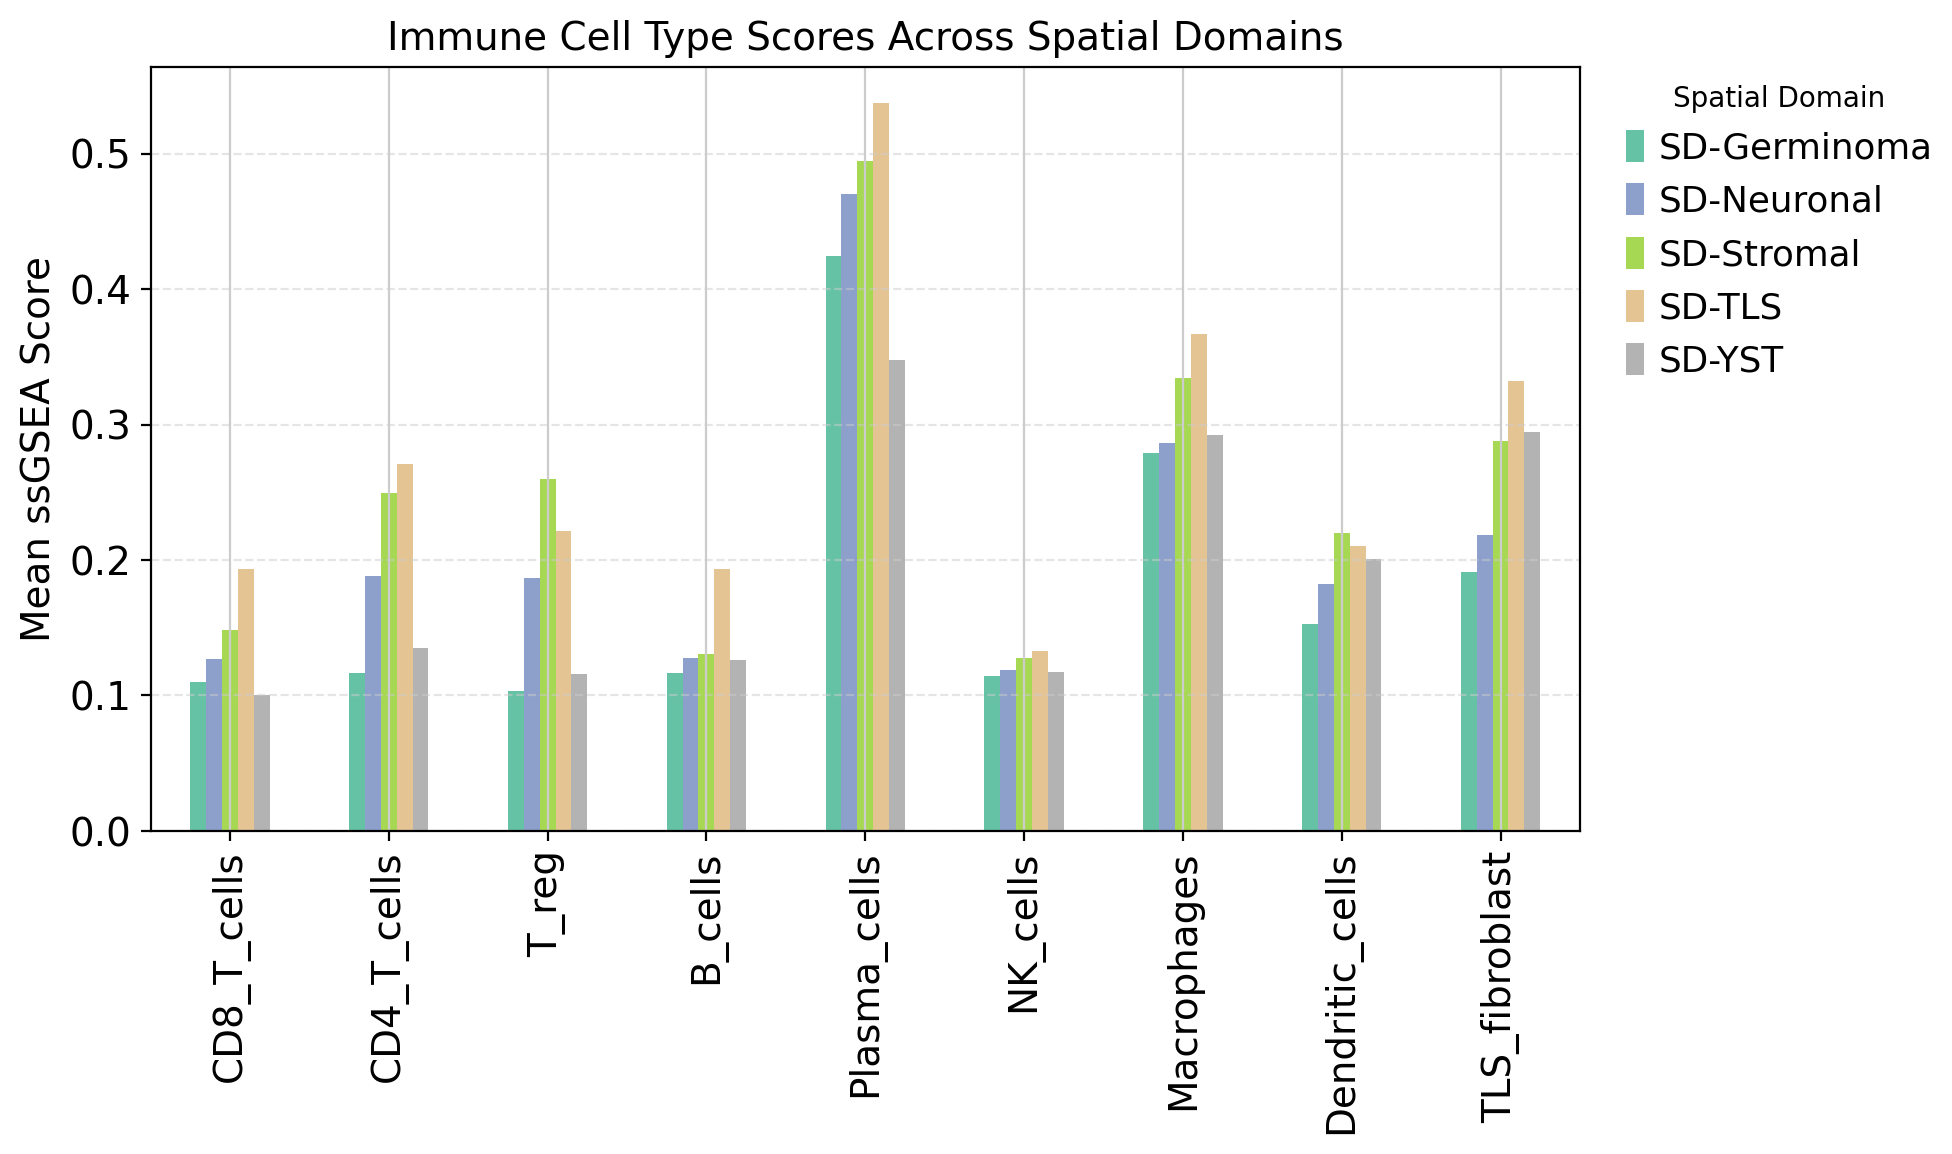

CD8_T_cells: Kruskal-Wallis p = 7.6325e-132
CD4_T_cells: Kruskal-Wallis p = 7.9847e-120
T_reg: Kruskal-Wallis p = 5.5511e-98
B_cells: Kruskal-Wallis p = 2.8075e-94
Plasma_cells: Kruskal-Wallis p = 2.0422e-119
NK_cells: Kruskal-Wallis p = 4.5501e-68
Macrophages: Kruskal-Wallis p = 2.4948e-34
Dendritic_cells: Kruskal-Wallis p = 1.4505e-83
TLS_fibroblast: Kruskal-Wallis p = 4.3740e-109


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

key_cts = ['CD8_T_cells', 'CD4_T_cells', 'T_reg', 'B_cells', 'Plasma_cells', 'NK_cells',
           'Macrophages', 'Dendritic_cells', 'TLS_fibroblast']

key_cts = [c for c in key_cts if c in adata.obs.columns]

domain_means = adata.obs.groupby('spatial_domain')[key_cts].mean()

ax = domain_means.T.plot(kind='bar', figsize=(10, 6), colormap='Set2')
ax.set_ylabel('Mean ssGSEA Score')
ax.set_title('Immune Cell Type Scores Across Spatial Domains')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Spatial Domain', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('immune_scores_by_SD.pdf', dpi=150, bbox_inches='tight')
plt.show()

from scipy.stats import kruskal
sd_groups = [adata.obs['spatial_domain'].unique()]
for ct in key_cts:
    groups = [adata.obs.loc[adata.obs['spatial_domain'] == d, ct].values for d in adata.obs['spatial_domain'].unique()]
    stat, p = kruskal(*groups)
    print(f"{ct}: Kruskal-Wallis p = {p:.4e}")

/tmp/ipykernel_6283/2356336587.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  domain_means = adata.obs.groupby('spatial_domain')[key_cts].mean()


SD-TLS Immune_cell rank (average ssGSEA)：
Plasma_cells       0.537530
Macrophages        0.366992
TLS_fibroblast     0.332072
CD4_T_cells        0.270815
T_reg              0.221174
Dendritic_cells    0.210161
B_cells            0.193744
CD8_T_cells        0.193547
NK_cells           0.132757
Name: SD-TLS, dtype: float64


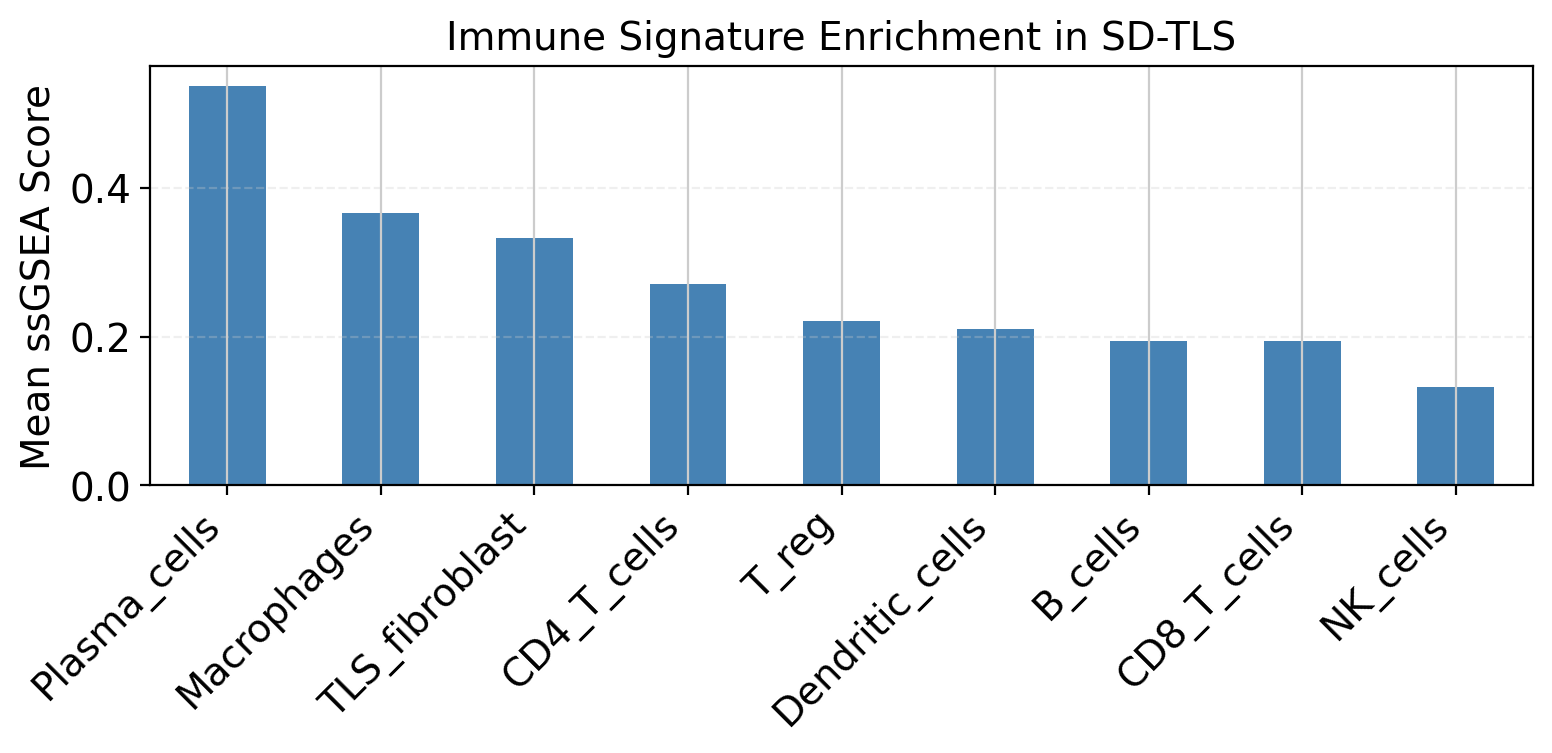

In [25]:
key_cts = ['CD8_T_cells', 'CD4_T_cells', 'T_reg', 'B_cells', 'Plasma_cells',
           'NK_cells', 'Macrophages', 'Dendritic_cells', 'TLS_fibroblast']
key_cts = [c for c in key_cts if c in adata.obs.columns]

domain_means = adata.obs.groupby('spatial_domain')[key_cts].mean()

tls_means = domain_means.loc['SD-TLS']

tls_sorted = tls_means.sort_values(ascending=False)
print("SD-TLS Immune_cell rank (average ssGSEA)：")
print(tls_sorted)

fig, ax = plt.subplots(figsize=(8, 4))
tls_sorted.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Immune Signature Enrichment in SD-TLS')
ax.set_ylabel('Mean ssGSEA Score')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('TLS_composition.pdf', dpi=150, bbox_inches='tight')
plt.show()

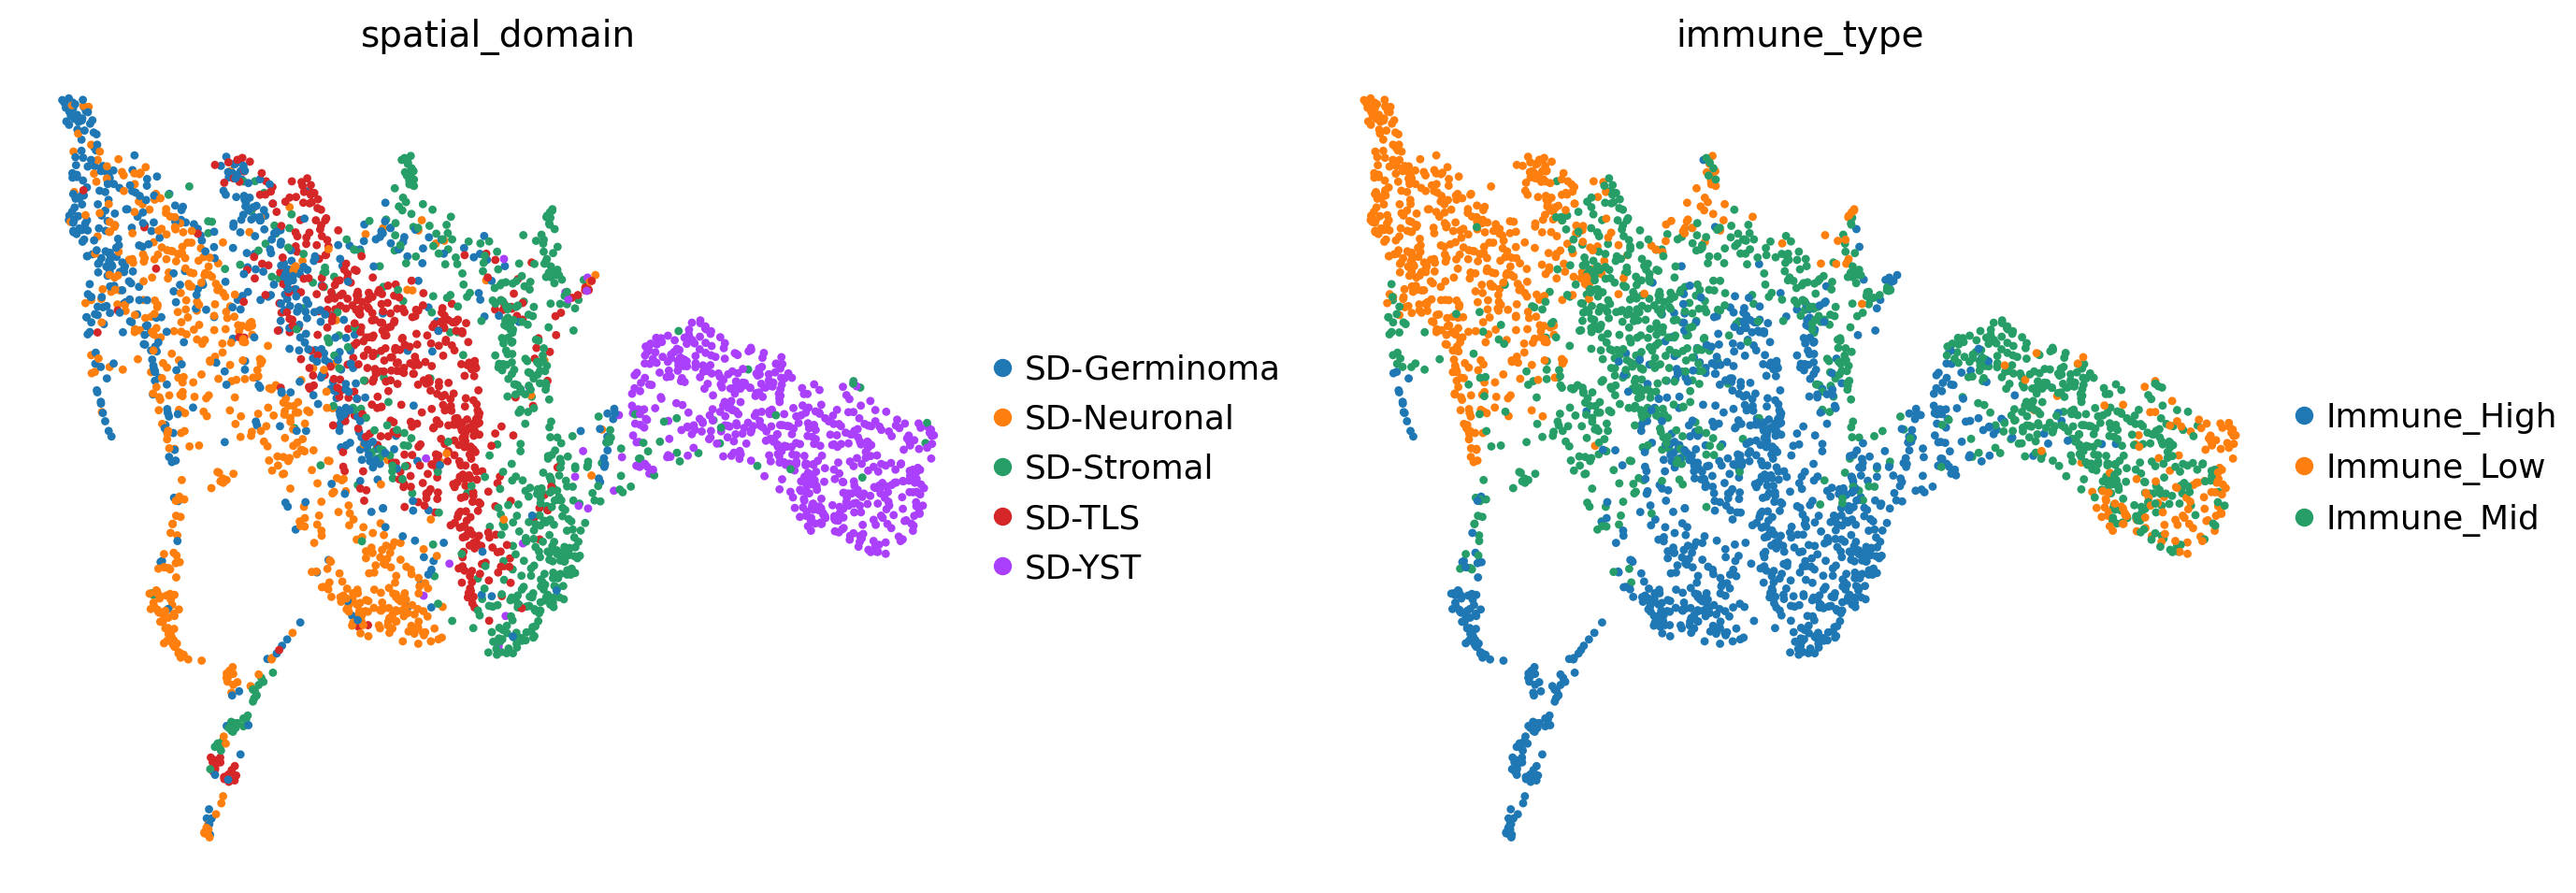

In [20]:
sc.tl.pca(adata, n_comps=15)
sc.pp.neighbors(adata, n_pcs=15)
sc.tl.umap(adata)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata, color='spatial_domain', ax=axes[0], show=False)
sc.pl.umap(adata, color='immune_type', ax=axes[1], show=False)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()
plt.savefig('umap_domain_vs_immune.png', dpi=150)
plt.show()

/tmp/ipykernel_6283/2987912607.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=['TLS_fibroblast', 'CD8_T_cells', 'B_cells', 'Macrophages'], ncols=2, save='_key_scores.png')


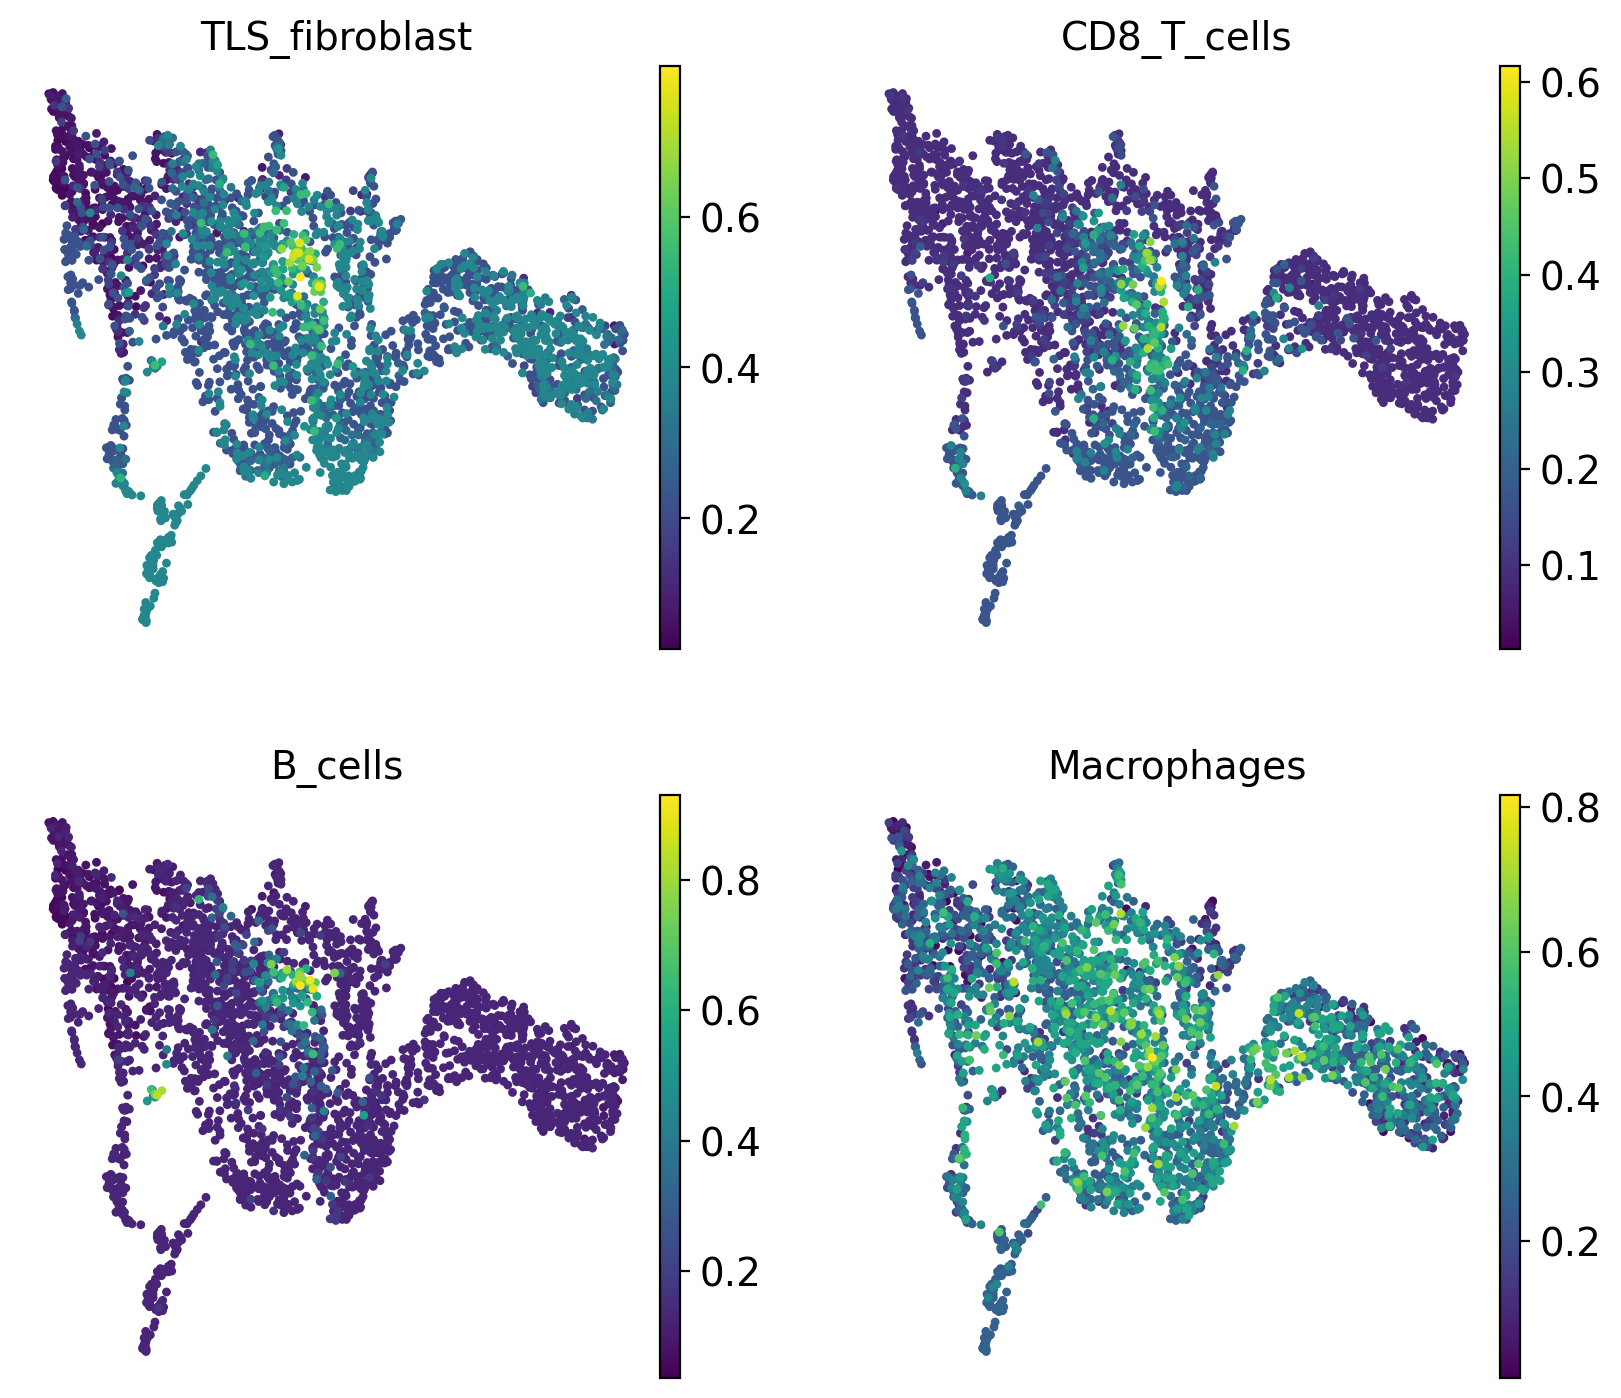

In [21]:
sc.tl.pca(adata, n_comps=15)
sc.pp.neighbors(adata, n_pcs=15)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['TLS_fibroblast', 'CD8_T_cells', 'B_cells', 'Macrophages'], ncols=2, save='_key_scores.png')

In [18]:
print(pd.crosstab(adata.obs['spatial_domain'], adata.obs['immune_type']))
adata.write("train_valid_immune_analyzed.h5ad", compression='gzip')

immune_type     Immune_High  Immune_Low  Immune_Mid
spatial_domain                                     
SD-Germinoma            105         305         185
SD-Neuronal             242         216         137
SD-Stromal              353          56         186
SD-TLS                  336          41         218
SD-YST                   78         125         392


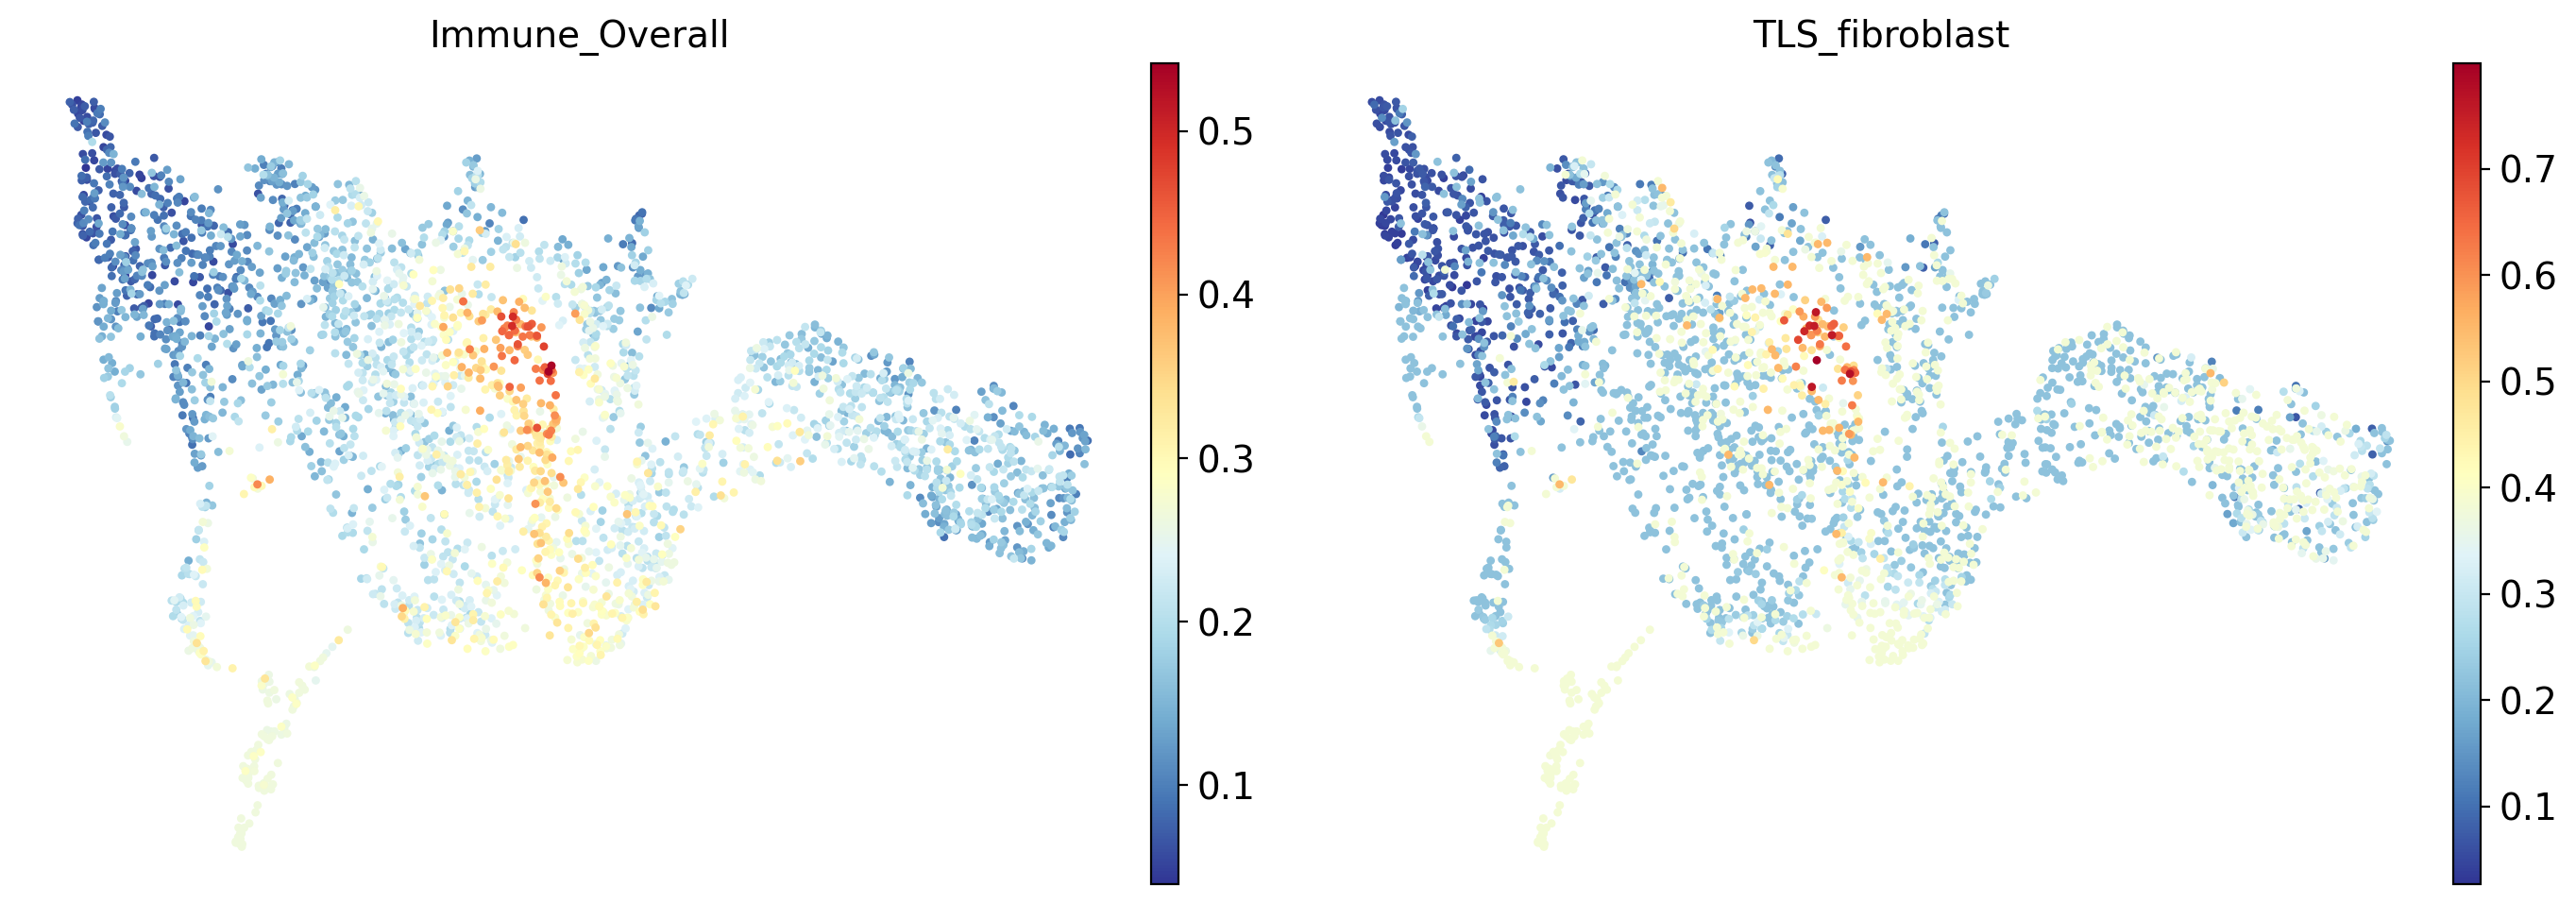

In [24]:
score_components = ['CD8_T_cells', 'CD4_T_cells', 'B_cells', 'Macrophages', 'TLS_fibroblast']
score_components = [c for c in score_components if c in adata.obs.columns]
adata.obs['Immune_Overall'] = adata.obs[score_components].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata, color='Immune_Overall', ax=axes[0], show=False, cmap='RdYlBu_r')
sc.pl.umap(adata, color='TLS_fibroblast', ax=axes[1], show=False, cmap='RdYlBu_r')

plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.savefig('umap_immune_heatmap.png', dpi=150)
plt.show()